In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
class SignalDetection:
    """
    A class to perform Signal Detection Theory analysis.
     - calculates sensitivity (d') and decision bias (criterion),
     - supports arithmetic operations between SDT experimental results,
     - provides methods for plotting distributions and ROC curves.

    Attributes:
        hits (int): Number of signal-present trials where observer responded "Yes".
        misses (int): Number of signal-present trials where observer responded "No".
        false_alarm (int): Number of signal-absent trials where observer responded "Yes".
        correct_rejections (int): Number of signal-absent trials where observer responded "No".
    """
    def __init__(self, hits, misses, false_alarms, correct_rejections):
        self.__validate_count("hits", hits)
        self.__validate_count("misses", misses)
        self.__validate_count("false_alarms", false_alarms)
        self.__validate_count("correct_rejections", correct_rejections)
        self.__hits = int(hits)
        self.__misses = int(misses)
        self.__false_alarms = int(false_alarms)
        self.__correct_rejections = int(correct_rejections)

    def __validate_count(self, name, value):
        if isinstance(value,bool):
            raise TypeError(f"{name} must be an integer, got {value} instead")
        if not isinstance(value, int):
            raise TypeError(f"{name} must be an integer")
        if value < 0:
            raise ValueError(f"{name} must be a non-negative integer")

    def hit_rate(self):
        total = self.__hits + self.__misses
        # avoid division by zero
        if total == 0:
            return float('nan')

        return self.__hits / total

    def false_alarm_rate(self):
        total = self.__false_alarms + self.__correct_rejections
        # avoid division by zero
        if total == 0:
            return float('nan') 

        return self.__false_alarms / total

    def d_prime(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)
        return d_prime

    def criterion(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        return -0.5 * (norm.ppf(hit_rate) + norm.ppf(fa_rate))
    
    
    def __add__(self,other):
        if not isinstance(other, SignalDetection):
            raise TypeError(
                "Only SignalDetection instances can be added together"
                )
        
        return SignalDetection(
            self.__hits + other.__hits,
            self.__misses + other.__misses,
            self.__false_alarms + other.__false_alarms,
            self.__correct_rejections + other.__correct_rejections
        )
    
    def __sub__(self,other):
        if not isinstance(other, SignalDetection):
            raise TypeError(
                "Only SignalDetection instances can be subtracted from each other"
                )
        
        return SignalDetection(
            self.__hits - other.__hits,
            self.__misses - other.__misses,
            self.__false_alarms - other.__false_alarms,
            self.__correct_rejections - other.__correct_rejections
        )
    
    def __mul__(self,factor):
        if not isinstance(factor, (int, float)):
            raise TypeError(
                "SignalDetection instances can only be multiplied by a scalar"
                )
        if isinstance(factor, float):
            raise TypeError(
                "SignalDetection instances can only be multiplied by an integer"
                )
        
        return SignalDetection(
            self.__hits * factor,
            self.__misses * factor,
            self.__false_alarms * factor,
            self.__correct_rejections * factor
        )
    
    def plot_sdt(self):
        d_prime = self.d_prime()
        criterion = self.criterion()
        criterion_line = d_prime /2 + criterion

        x = np.linspace(-4, d_prime + 4, 1000)

        noise_dist = norm.pdf(x, loc=0, scale=1)
        signal_dist = norm.pdf(x, loc=d_prime, scale=1)

        fig, ax  = plt.subplots(figsize=(10, 6))

        ax.plot(x, noise_dist, label='Noise', color='blue')
        ax.plot(x, signal_dist, label='Signal', color='pink')

        ax.axvline(
            criterion_line, color='red', linestyle='--', label='Criterion'
            )
        
        # adding vidual indication of d prime
        y_top = max(max(noise_dist), max(signal_dist)) * 1.02

        ax.annotate(
            "", xy=(d_prime, y_top), xytext=(0, y_top),
            arrowprops=dict(arrowstyle="<->", color="#241B1B"),
        )
        ax.text(d_prime / 2, y_top * 1.03, f"d' = {d_prime:.2f}",
                ha="center", color="gray")

        ax.set_xlabel("Evidence")
        ax.set_ylabel("Probability density")
        ax.set_title("Signal Detection Theory")
        ax.legend(loc = "upper right")
        ax.grid(True)

        # add y limit to make space for d prime annotation
        ax.set_ylim(0, y_top + 0.04)

        return fig,ax
    
    @staticmethod 
    def plot_roc(sdt_list):
        if not all(isinstance(s, SignalDetection) for s in sdt_list):
            raise TypeError(
                "plot_roc requires a sequence of SignalDetection objects"
                )
        
        hit_rates = [s.hit_rate() for s in sdt_list]
        fa_rates = [s.false_alarm_rate() for s in sdt_list]

        # sort the points 
        sorted_indices = np.argsort(hit_rates)
        hit_rates = [hit_rates[i] for i in sorted_indices]
        fa_rates = [fa_rates[i] for i in sorted_indices]
        

        # add endpoints for the ROC curve
        hit_rates = [0] + hit_rates + [1]
        fa_rates = [0] + fa_rates + [1]
        

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.plot(hit_rates, fa_rates, marker='o', label='ROC Curve')
        ax.plot(
            [0, 1], [0, 1], linestyle='--',
            color='gray', label='Chance Level'
            )
        ax.set_ylabel('False Alarm Rate')
        ax.set_xlabel('Hit Rate')
        ax.set_title('ROC Curve')
        ax.legend(loc='lower right')
        ax.grid(True)
        
        return fig, ax
        

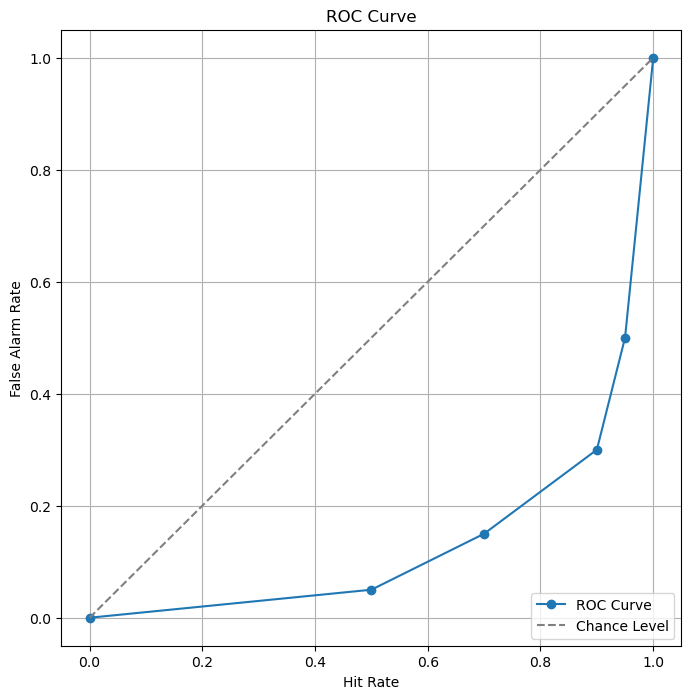

In [155]:
sdts = [
    SignalDetection(90, 10, 30, 70),
    SignalDetection(70, 30, 15, 85),
    SignalDetection(50, 50, 5, 95),
    SignalDetection(95, 5, 50, 50),
]
fig, ax = SignalDetection.plot_roc(sdts)
plt.show()
